# EquiRelief — Week 2: Full NLP Pipeline (Corrected)

## What changed from v1
- **Stage 1**: Loads CrisisNLP + Figure Eight + Kerala TSV + Manual test set correctly
- **Stage 8**: Replaces BART (English-only) with fine-tuned mDeBERTa-v3 (all 5 languages)
- **Stage 7**: Evaluates resource extraction against Figure Eight ground truth labels
- **Stages 6-10**: Only run region/resource/dedup/aggregation on the right subset
- Kerala floods TSV extracted separately as domain test set

## Data routing
| Dataset | Used for |
|---|---|
| CrisisNLP (76k EN) | Urgency classifier fine-tuning (train/dev/test) |
| Figure Eight (26k EN) | Urgency fine-tuning + resource extraction eval |
| Kerala floods TSV (7.9k EN) | Domain-specific region+urgency test set |
| Manual test set (180, all 5 langs) | Full pipeline eval + final demand vector |
| Floods synthetic (12 rows) | End-to-end demo |

**Runtime**: GPU T4 required. Runtime → Change runtime type → T4 GPU.

## Cell 1 — Mount + restore environment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
BASE = '/content/drive/MyDrive/Equi-Relief'

!ls /content/drive/MyDrive/Equi-Relief

os.environ['HF_HOME']                    = f'{BASE}/models/hf_cache'
os.environ['TRANSFORMERS_CACHE']         = f'{BASE}/models/hf_cache'
os.environ['HF_DATASETS_CACHE']          = f'{BASE}/models/hf_cache/datasets'
os.environ['SENTENCE_TRANSFORMERS_HOME'] = f'{BASE}/models/hf_cache/sentence_transformers'

if f'{BASE}/notebooks' not in sys.path:
    sys.path.insert(0, f'{BASE}/notebooks')

import config, utils
utils.set_seed(config.SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Regions: {config.REGIONS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data  models  notebooks  outputs
Device : cuda
GPU    : Tesla T4
Regions: ['north', 'south', 'east', 'west', 'central']


In [3]:
%%capture
!pip install -q transformers==4.38.2 datasets sentence-transformers peft \
    indic-nlp-library langdetect hdbscan scikit-learn \
    pandas numpy tqdm matplotlib seaborn
print('Done.')

In [4]:
!pip uninstall -y peft transformers accelerate
!pip install -q transformers==4.38.2 accelerate==0.27.2
print('Uninstalled and re-installed transformers and accelerate to compatible versions.')

Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 7.0 MB/s eta 0:00:00
Uninstalled and re-installed transformers and accelerate to compatible versions.


In [2]:
import glob, re, json, unicodedata, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datasets import load_from_disk
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings('ignore')
tqdm.pandas()
pd.set_option('display.max_colwidth', 100)

def section(t):
    print('\n' + '='*60)
    print(f'  {t}')
    print('='*60)

print('Imports OK.')

Imports OK.


---
# Stage 1 — Data Loading

Load all four sources and route them correctly:
- CrisisNLP + Figure Eight → urgency fine-tuning pool
- Kerala floods TSV → domain test set  
- Manual test set → full pipeline evaluation
- Floods synthetic → end-to-end demo

In [3]:
section('Stage 1a — Load CrisisNLP')

CRISIS_ROOTS = [
    f'{BASE}/data/raw/crisisnlp/events_set1',
    f'{BASE}/data/raw/crisisnlp/events_set2',
]

CRISIS_URGENT = {
    'affected_individuals',
    'displaced_people_and_evacuations',
    'infrastructure_and_utility_damage',
    'rescue_volunteering_or_donation_effort',
    'requests_or_urgent_needs',
    'injured_or_dead_people',
    'missing_or_found_people',
}
CRISIS_NON_URGENT = {
    'caution_and_advice',
    'not_related_or_irrelevant',
    'other_useful_information',
    'sympathy_and_support',
    'not_humanitarian',
    'dont_know_cant_judge',
    'other_relevant_information',
}

frames = []
for root in CRISIS_ROOTS:
    for fpath in sorted(glob.glob(f'{root}/**/*.tsv', recursive=True)):
        try:
            tmp = pd.read_csv(fpath, sep='\t', dtype=str)
            tmp.columns = [c.strip().lower() for c in tmp.columns]
            rename = {'tweetid':'tweet_id','text':'tweet_text','label':'class_label'}
            tmp.rename(columns={k:v for k,v in rename.items() if k in tmp.columns}, inplace=True)
            fname = os.path.basename(fpath)
            for sp in ['train','dev','test']:
                if fname.endswith(f'_{sp}.tsv'):
                    tmp['split'] = sp
                    tmp['event'] = fname.replace(f'_{sp}.tsv','')
                    break
            else:
                tmp['split'] = 'unknown'
                tmp['event'] = fname.replace('.tsv','')
            tmp['source'] = 'crisisnlp'
            frames.append(tmp)
        except Exception as e:
            print(f'  skip {fpath}: {e}')

df_crisis = pd.concat(frames, ignore_index=True)
df_crisis['tweet_text'] = df_crisis['tweet_text'].astype(str).str.strip()
df_crisis['urgency'] = df_crisis['class_label'].apply(
    lambda l: 1 if str(l).lower() in CRISIS_URGENT
              else (0 if str(l).lower() in CRISIS_NON_URGENT else -1)
)
df_crisis = df_crisis[df_crisis['urgency'] != -1].copy()
df_crisis['lang'] = 'en'

# Extract Kerala floods as separate domain test set
df_kerala = df_crisis[df_crisis['event'] == 'kerala_floods_2018'].copy()
df_crisis_no_kerala = df_crisis[df_crisis['event'] != 'kerala_floods_2018'].copy()

print(f'CrisisNLP total   : {len(df_crisis):,}')
print(f'  excl. Kerala    : {len(df_crisis_no_kerala):,}')
print(f'Kerala domain test: {len(df_kerala):,}')
print(f'  urgent          : {df_kerala["urgency"].mean():.1%}')
print(f'CrisisNLP balance : {df_crisis_no_kerala["urgency"].mean():.1%} urgent')


  Stage 1a — Load CrisisNLP
CrisisNLP total   : 76,484
  excl. Kerala    : 68,500
Kerala domain test: 7,984
  urgent          : 70.1%
CrisisNLP balance : 55.6% urgent


In [4]:
section('Stage 1b — Load Figure Eight (humaid folder)')

ds_fig8   = load_from_disk(f'{BASE}/data/raw/humaid')
fig8_frames = []
for sp in ds_fig8:
    tmp = ds_fig8[sp].to_pandas()
    tmp['split'] = sp
    fig8_frames.append(tmp)

df_fig8 = pd.concat(fig8_frames, ignore_index=True)
df_fig8.columns = [c.lower() for c in df_fig8.columns]
df_fig8.rename(columns={'message':'tweet_text'}, inplace=True)
df_fig8['tweet_text'] = df_fig8['tweet_text'].astype(str)
df_fig8['lang']   = 'en'
df_fig8['source'] = 'figureeight'

# Urgency from binary columns
URGENCY_COLS_F8 = [
    'request','medical_help','medical_products',
    'search_and_rescue','missing_people','death','refugees',
]
df_fig8['urgency'] = df_fig8[URGENCY_COLS_F8].max(axis=1).astype(int)

# Resource ground truth — what CrisisNLP does NOT have
df_fig8['resource_food']     = df_fig8['food'].astype(int)
df_fig8['resource_water']    = df_fig8['water'].astype(int)
df_fig8['resource_medicine'] = df_fig8[['medical_help','medical_products']].max(axis=1).astype(int)

# Reliability flag — direct_report = eyewitness, more trustworthy
df_fig8['is_reliable'] = df_fig8['direct_report'].astype(int)

print(f'Figure Eight rows : {len(df_fig8):,}')
print(f'Balance           : {df_fig8["urgency"].mean():.1%} urgent')
print(f'Food labels       : {df_fig8["resource_food"].sum():,}')
print(f'Water labels      : {df_fig8["resource_water"].sum():,}')
print(f'Medicine labels   : {df_fig8["resource_medicine"].sum():,}')
print(f'Reliable (eyewitness): {df_fig8["is_reliable"].sum():,}')


  Stage 1b — Load Figure Eight (humaid folder)
Figure Eight rows : 26,248
Balance           : 29.9% urgent
Food labels       : 2,930
Water labels      : 1,674
Medicine labels   : 2,768
Reliable (eyewitness): 5,081


In [5]:
section('Stage 1c — Load manual test set + floods')

df_manual = pd.DataFrame(utils.load_json(f'{config.TEST_SET}/combined_180.json'))
df_manual.rename(columns={'text':'tweet_text'}, inplace=True)
df_manual['source'] = 'manual_test_set'

kerala_flood = utils.load_json(f'{config.DATA_RAW}/kerala_floods/synthetic_sample.json')
chennai_flood= utils.load_json(f'{config.DATA_RAW}/chennai_floods/synthetic_sample.json')
df_floods = pd.DataFrame(kerala_flood + chennai_flood)
df_floods.rename(columns={'text':'tweet_text'}, inplace=True)
df_floods['urgency'] = 1
df_floods['source']  = 'floods_synthetic'

print(f'Manual test set   : {len(df_manual):,} rows')
print(f'  lang dist       : {df_manual["lang"].value_counts().to_dict()}')
print(f'  urgent          : {df_manual["urgency"].mean():.1%}')
print(f'Floods synthetic  : {len(df_floods):,} rows')
print(f'  lang dist       : {df_floods["lang"].value_counts().to_dict()}')


  Stage 1c — Load manual test set + floods
Manual test set   : 180 rows
  lang dist       : {'hinglish': 60, 'tanglish': 60, 'en': 20, 'hi': 20, 'ta': 20}
  urgent          : 62.8%
Floods synthetic  : 12 rows
  lang dist       : {'en': 6, 'tanglish': 3, 'hinglish': 2, 'ml': 1}


In [6]:
section('Stage 1d — Build urgency training pool')

# Training pool = CrisisNLP (excl. Kerala) + Figure Eight
# Keep splits aligned: train/dev for training, test for evaluation

crisis_train = df_crisis_no_kerala[df_crisis_no_kerala['split']=='train'][['tweet_text','urgency','source']].copy()
crisis_dev   = df_crisis_no_kerala[df_crisis_no_kerala['split']=='dev'][['tweet_text','urgency','source']].copy()
crisis_test  = df_crisis_no_kerala[df_crisis_no_kerala['split']=='test'][['tweet_text','urgency','source']].copy()

fig8_train = df_fig8[df_fig8['split']=='train'][['tweet_text','urgency','source']].copy()
fig8_val   = df_fig8[df_fig8['split']=='validation'][['tweet_text','urgency','source']].copy()
fig8_test  = df_fig8[df_fig8['split']=='test'][['tweet_text','urgency','source']].copy()

df_urg_train = pd.concat([crisis_train, fig8_train], ignore_index=True).dropna(subset=['tweet_text','urgency'])
df_urg_val   = pd.concat([crisis_dev,   fig8_val],   ignore_index=True).dropna(subset=['tweet_text','urgency'])
df_urg_test  = pd.concat([crisis_test,  fig8_test],  ignore_index=True).dropna(subset=['tweet_text','urgency'])

df_urg_train['urgency'] = df_urg_train['urgency'].astype(int)
df_urg_val['urgency']   = df_urg_val['urgency'].astype(int)
df_urg_test['urgency']  = df_urg_test['urgency'].astype(int)

print(f'Urgency train : {len(df_urg_train):,}  ({df_urg_train["urgency"].mean():.1%} urgent)')
print(f'Urgency val   : {len(df_urg_val):,}  ({df_urg_val["urgency"].mean():.1%} urgent)')
print(f'Urgency test  : {len(df_urg_test):,}  ({df_urg_test["urgency"].mean():.1%} urgent)')
print(f'\nDomain test sets (NOT in training):')
print(f'  Kerala TSV    : {len(df_kerala):,}')
print(f'  Manual 180    : {len(df_manual):,}')


  Stage 1d — Build urgency training pool
Urgency train : 68,989  (47.8% urgent)
Urgency val   : 9,552  (48.4% urgent)
Urgency test  : 16,207  (51.7% urgent)

Domain test sets (NOT in training):
  Kerala TSV    : 7,984
  Manual 180    : 180


---
# Stage 2 — Language Detection

In [7]:
section('Stage 2 — Language Detection')

from langdetect import detect, DetectorFactory
DetectorFactory.seed = config.SEED

DEVANAGARI = (0x0900, 0x097F)
TAMIL_RANGE = (0x0B80, 0x0BFF)

def char_ratio(text, lo, hi):
    text = str(text)
    if not text: return 0.0
    return sum(1 for c in text if lo <= ord(c) <= hi) / len(text)

HINGLISH_MARKERS = {
    'karo','chahiye','nahi','paani','khana','bhai','mein','hai',
    'hain','bhejo','jaldi','bahut','log','gaya','khatam','yaar',
    'dawai','aur','nahi','mila','camp','help','karo','zaroor',
}
TANGLISH_MARKERS = {
    'venuma','pannunga','iruku','illai','thanni','saapadu',
    'marunthu','inga','anga','aayiduchu','varavilai','kudunga',
    'tharuma','romba','naal','panunga','vaanga','sollunga',
}

def detect_language(text, lang_hint=None):
    if lang_hint and lang_hint in config.LANGUAGES:
        return lang_hint
    text = str(text).strip()
    if not text: return 'en'

    dev_r = char_ratio(text, *DEVANAGARI)
    tam_r = char_ratio(text, *TAMIL_RANGE)

    if dev_r > 0.4: return 'hi'
    if tam_r > 0.4: return 'ta'
    if dev_r > 0.05: return 'hinglish'
    if tam_r > 0.05: return 'tanglish'

    try:
        detected = detect(text)
        if detected == 'hi': return 'hinglish'
        if detected == 'ta': return 'tanglish'
    except Exception:
        pass

    words = set(text.lower().split())
    if sum(1 for w in HINGLISH_MARKERS if w in words) >= 2: return 'hinglish'
    if sum(1 for w in TANGLISH_MARKERS if w in words) >= 2: return 'tanglish'
    return 'en'

# Apply to manual test set (has lang_hint ground truth)
df_manual['lang_detected'] = df_manual.apply(
    lambda r: detect_language(r['tweet_text'], r.get('lang')), axis=1
)
# Apply to floods
df_floods['lang_detected'] = df_floods.apply(
    lambda r: detect_language(r['tweet_text'], r.get('lang')), axis=1
)

# Evaluate on manual test set
lang_acc = (df_manual['lang_detected'] == df_manual['lang']).mean()
print(f'Language detection accuracy on manual test set: {lang_acc:.1%}')
print('\nPer-language breakdown:')
for lang in config.LANGUAGES:
    mask = df_manual['lang'] == lang
    acc  = (df_manual.loc[mask,'lang_detected'] == lang).mean()
    print(f'  {lang:<12} {acc:.1%}  (n={mask.sum()})')


  Stage 2 — Language Detection
Language detection accuracy on manual test set: 100.0%

Per-language breakdown:
  en           100.0%  (n=20)
  hi           100.0%  (n=20)
  ta           100.0%  (n=20)
  hinglish     100.0%  (n=60)
  tanglish     100.0%  (n=60)


---
# Stage 3 — Text Normalisation

In [8]:
section('Stage 3 — Text Normalisation')

try:
    from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
    _factory = IndicNormalizerFactory()
    _hi_norm = _factory.get_normalizer('hi')
    _ta_norm = _factory.get_normalizer('ta')
    INDIC_OK = True
    print('IndicNLP normalisers loaded.')
except Exception as e:
    INDIC_OK = False
    print(f'IndicNLP not available: {e}. Skipping script normalisation.')

def normalise(text, lang):
    text = str(text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'^RT\s*:?\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    if INDIC_OK:
        if lang == 'hi':  text = _hi_norm.normalize(text)
        elif lang == 'ta': text = _ta_norm.normalize(text)
    return re.sub(r'\s+', ' ', text).strip()

# Apply normalisation
# Training pool — English only, fast
df_urg_train['text_clean'] = df_urg_train['tweet_text'].apply(lambda t: normalise(t, 'en'))
df_urg_val['text_clean']   = df_urg_val['tweet_text'].apply(lambda t: normalise(t, 'en'))
df_urg_test['text_clean']  = df_urg_test['tweet_text'].apply(lambda t: normalise(t, 'en'))

# Manual test set — use detected language
df_manual['text_clean'] = df_manual.progress_apply(
    lambda r: normalise(r['tweet_text'], r['lang_detected']), axis=1
)
# Floods
df_floods['text_clean'] = df_floods.progress_apply(
    lambda r: normalise(r['tweet_text'], r['lang_detected']), axis=1
)
# Kerala domain test
df_kerala['text_clean'] = df_kerala['tweet_text'].apply(lambda t: normalise(t, 'en'))

print('Normalisation complete.')
print('\nBefore / After examples (manual test set):')
for _, r in df_manual[df_manual['lang'].isin(['hinglish','tanglish'])].head(3).iterrows():
    print(f'  [{r["lang"]}]')
    print(f'  Before: {r["tweet_text"][:80]}')
    print(f'  After : {r["text_clean"][:80]}')
    print()


  Stage 3 — Text Normalisation
IndicNLP normalisers loaded.


  0%|          | 0/180 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Normalisation complete.

Before / After examples (manual test set):
  [hinglish]
  Before: Yaar flood aa gaya, khaana chahiye urgently north sector mein
  After : Yaar flood aa gaya, khaana chahiye urgently north sector mein

  [hinglish]
  Before: Bhaiya please khana bhejo, 2 din se kuch nahi mila east camp
  After : Bhaiya please khana bhejo, 2 din se kuch nahi mila east camp

  [hinglish]
  Before: Relief camp mein khana khatam ho gaya, immediately send karo
  After : Relief camp mein khana khatam ho gaya, immediately send karo



---
# Stage 4 — Tokenisation

In [9]:
section('Stage 4 — Tokenisation (mBERT + IndicBERT)')

from transformers import AutoTokenizer

print('Loading tokenisers...')
tok_mbert = AutoTokenizer.from_pretrained(config.MODELS['mbert'])
tok_indic = AutoTokenizer.from_pretrained(config.MODELS['indicbert'])
print('Tokenisers loaded.')

def tokenise(text, lang):
    tok = tok_indic if lang in ('hi','ta') else tok_mbert
    return tok(
        text,
        max_length=config.NLP['max_length'],
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

# Token length stats on training pool
sample_lens = []
for t in df_urg_train['text_clean'].sample(500, random_state=42):
    enc = tok_mbert(t, truncation=True, max_length=128)
    sample_lens.append(sum(enc['attention_mask']))

sample_lens = np.array(sample_lens)
print(f'Token length stats (sample 500 from training pool):')
print(f'  Mean   : {sample_lens.mean():.1f}')
print(f'  Median : {np.median(sample_lens):.0f}')
print(f'  95th % : {np.percentile(sample_lens, 95):.0f}')
print(f'  > 128  : {(sample_lens >= 128).mean():.1%}  (truncated)')
print(f'\nmax_length=128 covers {(sample_lens < 128).mean():.1%} of tokens without truncation.')


  Stage 4 — Tokenisation (mBERT + IndicBERT)
Loading tokenisers...
Tokenisers loaded.
Token length stats (sample 500 from training pool):
  Mean   : 32.9
  Median : 30
  95th % : 64
  > 128  : 0.0%  (truncated)

max_length=128 covers 100.0% of tokens without truncation.


---
# Stage 5 — Multilingual Embeddings

In [10]:
section('Stage 5 — Load mBERT + IndicBERT for embeddings')

from transformers import AutoModel

print('Loading mBERT...')
model_mbert = AutoModel.from_pretrained(config.MODELS['mbert']).to(DEVICE).eval()
print('Loading IndicBERT...')
model_indic = AutoModel.from_pretrained(config.MODELS['indicbert']).to(DEVICE).eval()
print('Both loaded.')


  Stage 5 — Load mBERT + IndicBERT for embeddings
Loading mBERT...
Loading IndicBERT...
Both loaded.


In [11]:
def embed_batch(texts, langs, batch_size=32):
    """
    Produce [CLS] embeddings. Routes hi/ta to IndicBERT, rest to mBERT.
    Returns numpy array (N, hidden_dim).
    """
    all_emb = []
    for start in tqdm(range(0, len(texts), batch_size), desc='Embedding'):
        b_texts = texts[start:start+batch_size]
        b_langs = langs[start:start+batch_size]

        indic_idx = [i for i,l in enumerate(b_langs) if l in ('hi','ta')]
        other_idx = [i for i,l in enumerate(b_langs) if l not in ('hi','ta')]
        b_emb = [None] * len(b_texts)

        for idx_group, model, tok in [
            (indic_idx, model_indic, tok_indic),
            (other_idx, model_mbert, tok_mbert),
        ]:
            if not idx_group: continue
            sub = [b_texts[i] for i in idx_group]
            enc = tok(sub, max_length=128, truncation=True,
                      padding=True, return_tensors='pt').to(DEVICE)
            with torch.no_grad():
                out = model(**enc)
            cls = out.last_hidden_state[:,0,:].cpu().numpy()
            for li, oi in enumerate(idx_group):
                b_emb[oi] = cls[li]
        all_emb.extend(b_emb)
    return np.vstack(all_emb)

# Embed manual test set (all 5 languages — this is the key embedding)
print('Embedding manual test set (180 rows, all 5 languages)...')
emb_manual = embed_batch(
    df_manual['text_clean'].tolist(),
    df_manual['lang'].tolist(),
)
np.save(f'{config.DATA_PROC}/emb_manual_mbert_indic.npy', emb_manual)
print(f'Shape: {emb_manual.shape}')

# Embed Kerala domain test set
print('\nEmbedding Kerala domain test set (7.9k rows)...')
emb_kerala = embed_batch(
    df_kerala['text_clean'].tolist(),
    ['en'] * len(df_kerala),
)
np.save(f'{config.DATA_PROC}/emb_kerala_mbert.npy', emb_kerala)
print(f'Shape: {emb_kerala.shape}')

Embedding manual test set (180 rows, all 5 languages)...


Embedding:   0%|          | 0/6 [00:00<?, ?it/s]

Shape: (180, 768)

Embedding Kerala domain test set (7.9k rows)...


Embedding:   0%|          | 0/250 [00:00<?, ?it/s]

Shape: (7984, 768)


---
# Stage 6 — NER (Named Entity Recognition)

In [12]:
section('Stage 6 ? NER with Davlan mBERT')

from transformers import pipeline as hf_pipeline
import transformers
transformers.logging.set_verbosity_error()

print('Loading NER model...')
ner_pipe = hf_pipeline(
    'ner',
    model=config.MODELS['ner'],
    tokenizer=config.MODELS['ner'],
    aggregation_strategy='simple',
    device=0 if DEVICE=='cuda' else -1
)
print('NER loaded.')

REGION_GROUPS = {
    'north': [
        'north', 'northern', 'jammu and kashmir', 'jammu', 'kashmir', 'srinagar',
        'ladakh', 'leh', 'himachal pradesh', 'shimla', 'manali', 'dharamshala',
        'punjab', 'amritsar', 'ludhiana', 'haryana', 'chandigarh', 'gurgaon',
        'gurugram', 'faridabad', 'kurukshetra', 'delhi', 'new delhi', 'ncr',
        'uttarakhand', 'dehradun', 'haridwar', 'rishikesh', 'uttar pradesh',
        'lucknow', 'kanpur', 'agra', 'varanasi', 'prayagraj', 'allahabad',
        'meerut', 'noida', 'ghaziabad'
    ],
    'south': [
        'south', 'southern', 'kerala', 'thiruvananthapuram', 'trivandrum', 'kollam',
        'pathanamthitta', 'alappuzha', 'alleppey', 'kottayam', 'idukki',
        'ernakulam', 'kochi', 'cochin', 'thrissur', 'trichur', 'palakkad',
        'palghat', 'malappuram', 'kozhikode', 'calicut', 'wayanad', 'kannur',
        'kasaragod', 'aluva', 'munnar', 'chengannur', 'chalakudy', 'perumbavoor',
        'muvattupuzha', 'tamil nadu', 'chennai', 'madras', 'coimbatore', 'kovai',
        'madurai', 'tiruchirappalli', 'trichy', 'salem', 'tirunelveli', 'nellai',
        'vellore', 'cuddalore', 'nagapattinam', 'thanjavur', 'tanjore',
        'kanchipuram', 'chengalpattu', 'tiruvallur', 'tambaram', 'velachery',
        'anna nagar', 'maduravoyal', 'porur', 'karnataka', 'bengaluru', 'bangalore',
        'mysuru', 'mysore', 'mangaluru', 'mangalore', 'hubli', 'dharwad', 'udupi',
        'andhra pradesh', 'visakhapatnam', 'vizag', 'vijayawada', 'guntur',
        'tirupati', 'nellore', 'kurnool', 'telangana', 'hyderabad', 'warangal',
        'nizamabad', 'karimnagar', 'khammam', 'puducherry', 'pondicherry',
        'andaman and nicobar', 'port blair', 'lakshadweep'
    ],
    'east': [
        'east', 'eastern', 'west bengal', 'kolkata', 'howrah', 'siliguri',
        'darjeeling', 'durgapur', 'asansol', 'bihar', 'patna', 'gaya', 'muzaffarpur',
        'jharkhand', 'ranchi', 'jamshedpur', 'dhanbad', 'odisha', 'orissa',
        'bhubaneswar', 'cuttack', 'puri', 'sambalpur', 'assam', 'guwahati',
        'dibrugarh', 'silchar', 'meghalaya', 'shillong', 'tripura', 'agartala',
        'manipur', 'imphal', 'mizoram', 'aizawl', 'nagaland', 'kohima', 'dimapur',
        'arunachal pradesh', 'itanagar', 'sikkim', 'gangtok'
    ],
    'west': [
        'west', 'western', 'rajasthan', 'jaipur', 'jodhpur', 'udaipur', 'ajmer',
        'kota', 'bikaner', 'gujarat', 'ahmedabad', 'surat', 'vadodara', 'rajkot',
        'kachchh', 'kutch', 'maharashtra', 'mumbai', 'bombay', 'pune', 'nagpur',
        'nashik', 'thane', 'aurangabad', 'kolhapur', 'goa', 'panaji', 'margao'
    ],
    'central': [
        'central', 'centre', 'madhya pradesh', 'bhopal', 'indore', 'gwalior',
        'jabalpur', 'ujjain', 'chhattisgarh', 'raipur', 'bilaspur', 'durg',
        'bhilai', 'jagdalpur', 'vidarbha', 'bundelkhand', 'central camp',
        'central zone', 'relief camp', 'rescue camp', 'medical camp', 'shelter',
        'hospital', 'clinic', 'town', 'city', 'district'
    ],
}

DIRECTION_HINTS = {
    'north sector': 'north', 'north area': 'north', 'north camp': 'north', 'north village': 'north',
    'north shelter': 'north', 'north district': 'north', 'north zone': 'north', 'north hospital': 'north',
    'south sector': 'south', 'south area': 'south', 'south camp': 'south', 'south village': 'south',
    'south shelter': 'south', 'south district': 'south', 'south zone': 'south', 'south hospital': 'south',
    'east sector': 'east', 'east area': 'east', 'east camp': 'east', 'east village': 'east',
    'east shelter': 'east', 'east district': 'east', 'east zone': 'east', 'east hospital': 'east',
    'west sector': 'west', 'west area': 'west', 'west camp': 'west', 'west village': 'west',
    'west shelter': 'west', 'west district': 'west', 'west zone': 'west', 'west hospital': 'west',
}

LOCATION_TO_REGION = {}
for region, names in REGION_GROUPS.items():
    for name in names:
        LOCATION_TO_REGION[name] = region
for name, region in DIRECTION_HINTS.items():
    LOCATION_TO_REGION[name] = region

SORTED_LOCATION_KEYS = sorted(LOCATION_TO_REGION.keys(), key=len, reverse=True)


def normalise_location_name(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def text_to_region(text, entities):
    text_norm = f" {normalise_location_name(text)} "

    for ent in entities:
        if ent.get('entity_group') in ('LOC', 'GPE'):
            loc = normalise_location_name(ent.get('word', ''))
            if not loc:
                continue
            if loc in LOCATION_TO_REGION:
                return LOCATION_TO_REGION[loc]
            for key in SORTED_LOCATION_KEYS:
                if f" {key} " in f" {loc} " or f" {loc} " in f" {key} ":
                    return LOCATION_TO_REGION[key]

    for key in SORTED_LOCATION_KEYS:
        if f" {key} " in text_norm:
            return LOCATION_TO_REGION[key]

    return 'central'


def extract_disaster_type(text):
    text_lower = text.lower()
    for dtype, kws in [
        ('flood',      ['flood','flooding','inundated','waterlogged','submerged','???????','????']),
        ('earthquake', ['earthquake','quake','tremor','seismic','???????????','?????']),
        ('cyclone',    ['cyclone','hurricane','typhoon','storm','?????','???????']),
        ('fire',       ['wildfire','fire','blaze','??','??']),
        ('landslide',  ['landslide','mudslide','??????????','???????']),
        ('epidemic',   ['epidemic','outbreak','cholera','dengue','disease']),
    ]:
        if any(kw in text_lower for kw in kws):
            return dtype
    return 'general'

print('NER helper functions defined.')

# Quick test
test_ner = [
    'People in Chennai need food urgently',
    'Heavy floods reported across Kerala districts',
    'Cyclone alerts issued for coastal West Bengal',
    'Villages near Jaipur need water tankers',
    'North sector hospital running out of medicine',
]
print('\nNER test on disaster sentences:')
for t in test_ner:
    ents   = ner_pipe(t)
    region = text_to_region(t, ents)
    dtype  = extract_disaster_type(t)
    print(f'  Text    : {t}')
    print(f'  Entities: {[(e["word"], e["entity_group"]) for e in ents]}')
    print(f'  Region  : {region}  |  Disaster: {dtype}')
    print()




  Stage 6 — NER with Davlan mBERT
Loading NER model...
NER loaded.
NER helper functions defined.

NER test on disaster sentences:
  Text    : People in Alappuzha need food urgently
  Entities: [('Alappuzha', 'LOC')]
  Region  : south  |  Disaster: general

  Text    : North sector hospital running out of medicine
  Entities: []
  Region  : north  |  Disaster: general

  Text    : Flood in Kozhikode, rescue teams needed
  Entities: [('Kozhikode', 'LOC')]
  Region  : north  |  Disaster: flood

  Text    : Relief camp at Tambaram needs water
  Entities: [('Tambaram', 'LOC')]
  Region  : south  |  Disaster: general



In [13]:
# Run NER on manual test set + floods (pipeline rows only)
# CrisisNLP and Figure Eight skip region extraction — they are training data only

section('Stage 6 — Run NER on pipeline rows (manual + floods + kerala)')

def run_ner_on_df(df, desc='NER', batch_size=64):
    texts = df['text_clean'].tolist()
    all_ents, all_regions, all_disasters = [], [], []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i:i+batch_size]
        try:
            batch_ents = ner_pipe(batch, batch_size=batch_size)
        except Exception:
            batch_ents = [[] for _ in batch]
        if isinstance(batch_ents, dict):
            batch_ents = [batch_ents]
        for text, ents in zip(batch, batch_ents):
            all_ents.append(ents)
            all_regions.append(text_to_region(text, ents))
            all_disasters.append(extract_disaster_type(text))
    df = df.copy()
    df['ner_entities']  = all_ents
    df['region_pred']   = all_regions
    df['disaster_type'] = all_disasters
    return df

df_manual = run_ner_on_df(df_manual, 'NER manual test set')
df_floods = run_ner_on_df(df_floods, 'NER floods')
df_kerala = run_ner_on_df(df_kerala, 'NER Kerala domain test')

# Evaluate region detection on manual test set (has ground truth)
reg_acc = (df_manual['region_pred'] == df_manual['region']).mean()
print(f'\nRegion detection accuracy (manual test set): {reg_acc:.1%}')
print('\nRegion distribution — manual test set:')
print(df_manual['region_pred'].value_counts().to_string())
print('\nRegion distribution — Kerala domain test:')
print(df_kerala['region_pred'].value_counts().to_string())


  Stage 6 — Run NER on pipeline rows (manual + floods + kerala)


NER manual test set:   0%|          | 0/3 [00:00<?, ?it/s]

NER floods:   0%|          | 0/1 [00:00<?, ?it/s]

NER Kerala domain test:   0%|          | 0/125 [00:00<?, ?it/s]


Region detection accuracy (manual test set): 81.7%

Region distribution — manual test set:
region_pred
central    70
west       28
east       28
north      27
south      27

Region distribution — Kerala domain test:
region_pred
central    6686
south       692
north       336
east        198
west         72


---
# Stage 7 — Resource Extraction

In [14]:
section('Stage 7 — Resource Extraction')

RESOURCE_KEYWORDS = {
    'food': [
        # English
        'food','meal','meals','rice','bread','ration','rations','packet','packets',
        'hungry','hunger','starving','feed','feeding','supplies','distribute',
        # Hinglish
        'khana','khaana','roti','chawal','anaj','bhojan','raashan',
        'bhukha','bhukhe','saapadu',
        # Tanglish
        'unavu','pasi','tiffin',
        # Devanagari
        'खाना','भोजन','राशन','अनाज',
        # Tamil
        'உணவு','சாப்பாடு',
    ],
    'water': [
        # English
        'water','drinking water','clean water','potable','dehydration',
        'thirsty','thirst','tanker','pipeline','water supply',
        # Hinglish
        'paani','pani','jal','neer',
        # Tanglish
        'thanni','tanni','kudikka',
        # Devanagari
        'पानी','जल',
        # Tamil
        'தண்ணீர்','நீர்',
    ],
    'medicine': [
        # English
        'medicine','medicines','medical','doctor','doctors','nurse','hospital',
        'clinic','ambulance','first aid','drugs','treatment','injured','injury',
        'wound','sick','illness','patient','patients','oxygen','ors','antivenom',
        'antibiotic','vaccine','cholera','dengue','malaria','diarrhea','diarrhoea',
        'health','healthcare','pharmacy','pills','tablet','injection',
        # Hinglish
        'dawai','dawa','ilaj','beemar','ghayil',
        # Tanglish
        'marunthu','tablet','injection',
        # Devanagari
        'दवाई','दवा','अस्पताल','इलाज','घायल',
        # Tamil
        'மருந்து','மருத்துவமனை','மருத்துவர்',
    ]
}

def extract_resources(text):
    text_lower = str(text).lower()
    found = [r for r, kws in RESOURCE_KEYWORDS.items()
             if any(kw in text_lower for kw in kws)]
    return found if found else ['food']  # default

# Apply to pipeline rows
df_manual['resources_pred'] = df_manual['text_clean'].progress_apply(extract_resources)
df_floods['resources_pred'] = df_floods['text_clean'].apply(extract_resources)

# Evaluate on manual test set (has ground truth)
mlb = MultiLabelBinarizer(classes=['food','water','medicine'])
y_true_manual = mlb.fit_transform(df_manual['resources'].tolist())
y_pred_manual = mlb.transform(df_manual['resources_pred'].tolist())
f1_manual = f1_score(y_true_manual, y_pred_manual, average='macro', zero_division=0)
print(f'Resource extraction F1 on manual test set (180 samples): {f1_manual:.3f}')

# Evaluate on Figure Eight test set (real ground truth labels)
df_fig8_test_eval = df_fig8[df_fig8['split']=='test'].copy()
df_fig8_test_eval['resources_pred'] = df_fig8_test_eval['tweet_text'].apply(extract_resources)

def fig8_to_resource_list(row):
    res = []
    if row['resource_food']     == 1: res.append('food')
    if row['resource_water']    == 1: res.append('water')
    if row['resource_medicine'] == 1: res.append('medicine')
    return res if res else []

df_fig8_test_eval['resources_true'] = df_fig8_test_eval.apply(fig8_to_resource_list, axis=1)
# Only evaluate rows that have at least one resource label
has_label = df_fig8_test_eval['resources_true'].apply(len) > 0
y_true_f8 = mlb.fit_transform(df_fig8_test_eval.loc[has_label,'resources_true'])
y_pred_f8 = mlb.transform(df_fig8_test_eval.loc[has_label,'resources_pred'])
f1_f8 = f1_score(y_true_f8, y_pred_f8, average='macro', zero_division=0)
print(f'Resource extraction F1 on Figure Eight test set ({has_label.sum():,} labelled rows): {f1_f8:.3f}')
print(f'\nNote: F1 on manual test (clean text) > Figure Eight (noisy tweets) is expected.')


  Stage 7 — Resource Extraction


  0%|          | 0/180 [00:00<?, ?it/s]

Resource extraction F1 on manual test set (180 samples): 0.724
Resource extraction F1 on Figure Eight test set (620 labelled rows): 0.787

Note: F1 on manual test (clean text) > Figure Eight (noisy tweets) is expected.


---
# Stage 8 — Urgency Classification
## Part A: Fine-tune mDeBERTa-v3 on CrisisNLP + Figure Eight
## Part B: Evaluate on English test, Kerala domain test, and multilingual manual test

In [15]:
section('Stage 8A — Fine-tune mDeBERTa-v3 for urgency')

from transformers import (
    AutoTokenizer as AutoTok,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset as TorchDataset

URGENCY_MODEL = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
URGENCY_CKPT  = f'{config.CKPT_DIR}/urgency_mdeberta'

print(f'Loading tokeniser: {URGENCY_MODEL}')
urg_tokenizer = AutoTok.from_pretrained(URGENCY_MODEL)
print('Tokeniser loaded.')

class UrgencyDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids'     : self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels'        : self.labels[idx]
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1'        : f1_score(labels, preds, average='macro'),
        'f1_urgent' : f1_score(labels, preds, pos_label=1),
        'f1_non_urg': f1_score(labels, preds, pos_label=0),
    }

print('\nBuilding datasets...')
train_ds = UrgencyDataset(df_urg_train['text_clean'], df_urg_train['urgency'], urg_tokenizer)
val_ds   = UrgencyDataset(df_urg_val['text_clean'],   df_urg_val['urgency'],   urg_tokenizer)
print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}')


  Stage 8A — Fine-tune mDeBERTa-v3 for urgency
Loading tokeniser: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Tokeniser loaded.

Building datasets...
Train: 68,989  |  Val: 9,552


In [16]:
# Check if fine-tuned model already exists on Drive
URGENCY_FINAL = f'{config.CKPT_DIR}/urgency_mdeberta_final'

if os.path.exists(f'{URGENCY_FINAL}/config.json'):
    print(f'Fine-tuned model found at {URGENCY_FINAL}')
    print('Loading saved model — skipping training.')
    print('To retrain, delete the folder and re-run this cell.')
    SKIP_TRAINING = True
else:
    print('No saved model found. Will fine-tune.')
    SKIP_TRAINING = False

No saved model found. Will fine-tune.


In [19]:
import torch

# Detect what precision is safe for this GPU
use_fp16  = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7
use_bf16  = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

# mDeBERTa works better with bf16 — use that if available, else disable fp16
if 'deberta' in URGENCY_MODEL.lower():
    use_fp16 = False   # DeBERTa-v3 breaks with fp16 gradient scaling
    print(f'mDeBERTa detected → fp16=False, bf16={use_bf16}')
else:
    use_bf16 = False
    print(f'Other model → fp16={use_fp16}, bf16=False')

if not SKIP_TRAINING:
    print(f'Loading base model: {URGENCY_MODEL}')
    urg_model = AutoModelForSequenceClassification.from_pretrained(
        URGENCY_MODEL,
        num_labels=2,
        ignore_mismatched_sizes=True
    )

    training_args = TrainingArguments(
        output_dir                  = URGENCY_CKPT,
        num_train_epochs            = 3,
        per_device_train_batch_size = 32,
        per_device_eval_batch_size  = 64,
        warmup_ratio                = 0.1,
        weight_decay                = 0.01,
        learning_rate               = 2e-5,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1',
        greater_is_better           = True,
        logging_steps               = 200,
        fp16                        = use_fp16,   # ← was hardcoded True
        bf16                        = use_bf16,   # ← new
        dataloader_num_workers      = 2,
        report_to                   = 'none',
    )

    trainer = Trainer(
        model           = urg_model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
    )

    print('\nStarting fine-tuning...')
    print(f'Estimated time on T4: ~25-35 minutes')
    trainer.train()

    trainer.save_model(URGENCY_FINAL)
    urg_tokenizer.save_pretrained(URGENCY_FINAL)
    print(f'\nSaved -> {URGENCY_FINAL}')

else:
    urg_model = AutoModelForSequenceClassification.from_pretrained(URGENCY_FINAL)
    urg_tokenizer = AutoTok.from_pretrained(URGENCY_FINAL)

    training_args = TrainingArguments(
        output_dir             = URGENCY_CKPT,
        per_device_eval_batch_size = 64,
        fp16                   = use_fp16,
        bf16                   = use_bf16,
        report_to              = 'none'
    )
    trainer = Trainer(
        model           = urg_model,
        args            = training_args,
        compute_metrics = compute_metrics
    )
    print('Model loaded from Drive.')

mDeBERTa detected → fp16=False, bf16=True
Loading base model: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'eval_strategy'

In [ ]:
# Run this to interrupt cleanly
trainer.control.should_training_stop = True

In [17]:
# ── Diagnose what's actually in train_ds ──────────────────────────────────
import numpy as np
from collections import Counter

# Check labels
labels = [train_ds[i]['labels'] for i in range(min(1000, len(train_ds)))]
print(f'Label distribution (first 1000): {Counter(labels)}')
print(f'Label dtype: {type(labels[0])}')
print(f'Label values: {set(labels)}')

# Check input ids look reasonable
sample = train_ds[0]
print(f'\nSample keys: {list(sample.keys())}')
print(f'input_ids length: {len(sample["input_ids"])}')
print(f'input_ids[:10]: {sample["input_ids"][:10]}')
print(f'label: {sample["labels"]}')

# Check a few decoded texts
print(f'\nDecoded sample text:')
print(urg_tokenizer.decode(sample['input_ids'], skip_special_tokens=True))

# Check total dataset size
print(f'\ntrain_ds size: {len(train_ds):,}')
print(f'val_ds size  : {len(val_ds):,}')

Label distribution (first 1000): Counter({tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor

In [18]:
import torch
from torch import nn
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

# ── Reload fresh model ────────────────────────────────────────────────────
urg_model = AutoModelForSequenceClassification.from_pretrained(
    URGENCY_MODEL,
    num_labels=2,
    ignore_mismatched_sizes=True,
)

# ── Class weights (same as before) ────────────────────────────────────────
class_weights = torch.tensor([0.958, 1.046], dtype=torch.float32).cuda()

In [19]:




class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        # Explicitly cast logits to float32 to match expected type by CrossEntropyLoss
        logits = outputs.logits.to(torch.float32)
        loss = nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir                  = URGENCY_CKPT,
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,       # back to safer LR
    lr_scheduler_type           = 'linear',
    evaluation_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_urgent',
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = False,
    bf16                        = False,       # ← disable bf16 entirely
    max_grad_norm               = 1.0,         # ← gradient clipping
    optim                       = 'adamw_torch',
    dataloader_num_workers      = 2,
    report_to                   = 'none',
)

trainer = WeightedTrainer(
    model           = urg_model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)

print('Restarting in fp32 with gradient clipping...')
print('Will be ~30% slower but stable')
print('Watch: loss at step 50 should be 0.60-0.70, grad_norm should be a real number')
trainer.train()

Restarting in fp32 with gradient clipping...
Will be ~30% slower but stable
Watch: loss at step 50 should be 0.60-0.70, grad_norm should be a real number
{'loss': 0.7569, 'grad_norm': 5.61196756362915, 'learning_rate': 4.63821892393321e-07, 'epoch': 0.01}
{'loss': 0.7179, 'grad_norm': 3.931548833847046, 'learning_rate': 9.27643784786642e-07, 'epoch': 0.02}
{'loss': 0.7106, 'grad_norm': 2.6720035076141357, 'learning_rate': 1.3914656771799632e-06, 'epoch': 0.03}
{'loss': 0.7006, 'grad_norm': 3.269519329071045, 'learning_rate': 1.855287569573284e-06, 'epoch': 0.05}
{'loss': 0.6896, 'grad_norm': 2.365023374557495, 'learning_rate': 2.319109461966605e-06, 'epoch': 0.06}
{'loss': 0.6807, 'grad_norm': 2.2387938499450684, 'learning_rate': 2.7829313543599264e-06, 'epoch': 0.07}
{'loss': 0.6616, 'grad_norm': 2.9231138229370117, 'learning_rate': 3.246753246753247e-06, 'epoch': 0.08}
{'loss': 0.6235, 'grad_norm': 5.186690807342529, 'learning_rate': 3.710575139146568e-06, 'epoch': 0.09}
{'loss': 0.5

TrainOutput(global_step=21560, training_loss=0.26427932627125883, metrics={'train_runtime': 12525.2854, 'train_samples_per_second': 27.54, 'train_steps_per_second': 1.721, 'train_loss': 0.26427932627125883, 'epoch': 5.0})

In [20]:
trainer.save_model(URGENCY_FINAL)
urg_tokenizer.save_pretrained(URGENCY_FINAL)
print(f'\nSaved -> {URGENCY_FINAL}')


Saved -> /content/drive/MyDrive/Equi-Relief/models/checkpoints/urgency_mdeberta_final


In [21]:
section('Stage 8B — Evaluate urgency on all test sets')

# 1. English CrisisNLP + Figure Eight test split
test_en_ds = UrgencyDataset(df_urg_test['text_clean'], df_urg_test['urgency'], urg_tokenizer)
results_en = trainer.evaluate(test_en_ds)
print(f'English test (CrisisNLP + Fig8): F1={results_en["eval_f1"]:.3f}  |  F1-urgent={results_en["eval_f1_urgent"]:.3f}')

# 2. Kerala domain test set
test_kerala_ds = UrgencyDataset(df_kerala['text_clean'], df_kerala['urgency'], urg_tokenizer)
preds_kerala   = np.argmax(trainer.predict(test_kerala_ds).predictions, axis=1)
f1_kerala = f1_score(df_kerala['urgency'].values, preds_kerala, average='macro')
print(f'Kerala domain test (7.9k rows) : F1={f1_kerala:.3f}')

# 3. Multilingual manual test set — the most important evaluation
test_multi_ds = UrgencyDataset(df_manual['text_clean'], df_manual['urgency'], urg_tokenizer)
preds_multi   = np.argmax(trainer.predict(test_multi_ds).predictions, axis=1)

print(f'\nMultilingual manual test set (180 samples):')
print(classification_report(
    df_manual['urgency'].values, preds_multi,
    target_names=['non-urgent','urgent']
))

print('Per-language urgency F1:')
df_manual['urgency_pred'] = preds_multi
for lang in config.LANGUAGES:
    mask = df_manual['lang'] == lang
    if mask.sum() == 0: continue
    f1 = f1_score(
        df_manual.loc[mask,'urgency'].values,
        df_manual.loc[mask,'urgency_pred'].values,
        average='macro', zero_division=0
    )
    n_correct = (df_manual.loc[mask,'urgency'] == df_manual.loc[mask,'urgency_pred']).sum()
    print(f'  {lang:<12} F1={f1:.3f}  acc={n_correct}/{mask.sum()}')


  Stage 8B — Evaluate urgency on all test sets
{'eval_loss': 0.3240112364292145, 'eval_f1': 0.8794147494677949, 'eval_f1_urgent': 0.8857092593678532, 'eval_f1_non_urg': 0.8731202395677364, 'eval_runtime': 151.4412, 'eval_samples_per_second': 107.018, 'eval_steps_per_second': 3.348, 'epoch': 5.0}
English test (CrisisNLP + Fig8): F1=0.879  |  F1-urgent=0.886
Kerala domain test (7.9k rows) : F1=0.829

Multilingual manual test set (180 samples):
              precision    recall  f1-score   support

  non-urgent       0.47      0.72      0.56        67
      urgent       0.75      0.51      0.61       113

    accuracy                           0.59       180
   macro avg       0.61      0.61      0.59       180
weighted avg       0.65      0.59      0.59       180

Per-language urgency F1:
  en           F1=0.792  acc=16/20
  hi           F1=0.688  acc=14/20
  ta           F1=0.749  acc=15/20
  hinglish     F1=0.517  acc=31/60
  tanglish     F1=0.499  acc=30/60


In [22]:
# Find the Hinglish/Tanglish rows that are being misclassified
mask_hing = df_manual['lang'] == 'hinglish'
wrong = df_manual[mask_hing & (df_manual['urgency'] != df_manual['urgency_pred'])]
print(f'Misclassified Hinglish: {len(wrong)}/60')
print('\nFalse negatives (urgent predicted as non-urgent):')
fn = wrong[wrong['urgency'] == 1]
for _, r in fn.head(10).iterrows():
    print(f'  {r["tweet_text"]}')
print('\nFalse positives (non-urgent predicted as urgent):')
fp = wrong[wrong['urgency'] == 0]
for _, r in fp.head(5).iterrows():
    print(f'  {r["tweet_text"]}')

Misclassified Hinglish: 29/60

False negatives (urgent predicted as non-urgent):
  Yaar flood aa gaya, khaana chahiye urgently north sector mein
  Bhaiya please khana bhejo, 2 din se kuch nahi mila east camp
  Relief camp mein khana khatam ho gaya, immediately send karo
  Bachhe bhukhe hain, central area mein ration nahi hai
  Village mein anaj bilkul nahi, please west zone help karo
  Paani nahi hai peene ko, south district mein pipes toot gaye
  Drinking water supply band ho gayi, north village crisis
  Saaf paani bhejo bhai, east shelter mein sab log beemar ho rahe
  Water tanker west camp nahi aaya 3 din se, urgent hai
  Dawai khatam ho gayi north hospital mein, immediately supply karo

False positives (non-urgent predicted as urgent):
  North camp mein volunteers aa rahe hain kal
  West area mein relief pahunch gayi, thanks to volunteers
  Central में सब ठीक है, volunteers aa gaye
  East mein rescue teams pahunch gayi, log safe hain


In [23]:
# Build urgency inference function for pipeline use
from transformers import pipeline as hf_pipeline

urgency_pipe = hf_pipeline(
    'text-classification',
    model     = URGENCY_FINAL,
    tokenizer = URGENCY_FINAL,
    device    = 0 if DEVICE == 'cuda' else -1
)

def get_urgency(text, lang=None):
    """
    Returns (urgency_int, confidence_score).
    Uses mDeBERTa for all languages — no language-specific routing needed.
    Falls back to keyword check if model confidence is low (<0.55).
    """
    result = urgency_pipe(str(text), truncation=True, max_length=128)
    label  = result[0]['label']   # LABEL_0 or LABEL_1
    score  = result[0]['score']
    pred   = 1 if label == 'LABEL_1' else 0

    # Low-confidence fallback — use keyword check
    if score < 0.55:
        urgent_kws = [
            'urgent','emergency','sos','help','trapped','dying','critical',
            # hinglish
            'chahiye','madad','bachao','jaldi','zaroor',
            # tanglish
            'venuma','urgent ah','help pannunga',
            # devanagari
            'जरूरत','मदद','बचाओ','तुरंत',
            # tamil
            'தேவை','உதவி','அவசரம்',
        ]
        text_lower = str(text).lower()
        if any(kw in text_lower for kw in urgent_kws):
            pred = 1

    return pred, round(score, 3)

# Quick test across all 5 languages
print('Urgency inference test:')
test_msgs = [
    ('People stranded, need food and water urgently',     'en'),
    ('उत्तर में भोजन और पानी की सख्त जरूरत है',         'hi'),
    ('வடக்கில் மக்கள் சிக்கியுள்ளனர், உணவு தேவை',     'ta'),
    ('Flood aa gaya, khana aur paani chahiye north mein', 'hinglish'),
    ('North la saapadu illai, urgent ah anupunga',        'tanglish'),
]
for msg, lang in test_msgs:
    pred, score = get_urgency(msg, lang)
    status = 'URGENT' if pred == 1 else 'non-urgent'
    print(f'  [{lang:<10}] {status} (score={score})  |  {msg[:60]}')

Urgency inference test:
  [en        ] URGENT (score=0.997)  |  People stranded, need food and water urgently
  [hi        ] URGENT (score=0.997)  |  उत्तर में भोजन और पानी की सख्त जरूरत है
  [ta        ] URGENT (score=0.995)  |  வடக்கில் மக்கள் சிக்கியுள்ளனர், உணவு தேவை
  [hinglish  ] non-urgent (score=0.97)  |  Flood aa gaya, khana aur paani chahiye north mein
  [tanglish  ] non-urgent (score=0.997)  |  North la saapadu illai, urgent ah anupunga


---
# Stage 9 — Cross-lingual Alignment + Deduplication
LaBSE + DBSCAN — run on manual test set + floods only

In [24]:
section('Stage 9 — LaBSE + DBSCAN deduplication')

from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN

print('Loading LaBSE...')
labse_model = SentenceTransformer(config.MODELS['labse'])
print('LaBSE loaded.')

# Combine manual test set + floods — these are the rows that need dedup
# (multilingual rows where cross-lingual duplicates can actually occur)
df_pipeline = pd.concat([
    df_manual[['tweet_text','text_clean','lang','urgency_pred','region_pred',
               'resources_pred','disaster_type','source']],
    df_floods[['tweet_text','text_clean','lang','region_pred',
               'resources_pred','disaster_type','source']].assign(urgency_pred=1),
], ignore_index=True)

print(f'Pipeline rows (manual + floods): {len(df_pipeline)}')
print(f'Language dist: {df_pipeline["lang"].value_counts().to_dict()}')

# LaBSE encode
print('\nEncoding with LaBSE...')
labse_emb = labse_model.encode(
    df_pipeline['text_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save(f'{config.DATA_PROC}/emb_pipeline_labse.npy', labse_emb)
print(f'LaBSE shape: {labse_emb.shape}')

# DBSCAN — eps=0.15 means cosine similarity >= 0.85 required to cluster
dbscan = DBSCAN(
    eps        = config.NLP['dbscan_eps'],   # 0.15
    min_samples= config.NLP['dbscan_min_samples'],
    metric     = 'cosine',
    n_jobs     = -1
)
cluster_labels = dbscan.fit_predict(labse_emb)
df_pipeline['cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()
before     = len(df_pipeline)

# Dedup: keep one per cluster (highest urgency, then first)
df_noise     = df_pipeline[df_pipeline['cluster'] == -1]
df_clustered = df_pipeline[df_pipeline['cluster'] >= 0]
df_dedup_cl  = (
    df_clustered
    .sort_values('urgency_pred', ascending=False)
    .groupby('cluster', as_index=False).first()
)
df_dedup = pd.concat([df_noise, df_dedup_cl], ignore_index=True)
after = len(df_dedup)

print(f'\nBefore dedup : {before}')
print(f'Clusters     : {n_clusters}')
print(f'Noise points : {n_noise} (unique)')
print(f'After dedup  : {after}')
print(f'Reduction    : {(before-after)/before:.1%}')

# Show any multi-language clusters found
print('\nMulti-language clusters:')
found_any = False
for cid in df_pipeline[df_pipeline['cluster']>=0]['cluster'].unique():
    members = df_pipeline[df_pipeline['cluster']==cid]
    if members['lang'].nunique() > 1:
        print(f'  Cluster {cid} ({len(members)} members):')
        for _, r in members.iterrows():
            print(f'    [{r["lang"]}] {r["text_clean"][:80]}')
        found_any = True
if not found_any:
    print('  None found — expected with small synthetic test set.')
    print('  Stage functions correctly; cross-lingual dedup activates in live deployment.')


  Stage 9 — LaBSE + DBSCAN deduplication
Loading LaBSE...


2_Dense/pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

LaBSE loaded.
Pipeline rows (manual + floods): 192
Language dist: {'tanglish': 63, 'hinglish': 62, 'en': 26, 'hi': 20, 'ta': 20, 'ml': 1}

Encoding with LaBSE...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

LaBSE shape: (192, 768)

Before dedup : 192
Clusters     : 39
Noise points : 83 (unique)
After dedup  : 122
Reduction    : 36.5%

Multi-language clusters:
  Cluster 2 (4 members):
    [hinglish] Village mein anaj bilkul nahi, please west zone help karo
    [hinglish] Cyclone ke baad south village mein kuch nahi, please help
    [hinglish] West mein earthquake ke baad sab kuch toot gaya, help karo
    [tanglish] West la earthquake, everything damaged, help pannunga
  Cluster 3 (6 members):
    [hinglish] Paani nahi hai peene ko, south district mein pipes toot gaye
    [hinglish] Saaf paani bhejo bhai, east shelter mein sab log beemar ho rahe
    [hinglish] East mein khana pahunch gaya, paani abhi bhi nahi
    [hinglish] South mein paani aa raha hai, sab log wahan jaayein
    [hinglish] South mein gaon poora doob gaya, koi nahi sun raha SOS
    [tanglish] South village muzhukka mazhaya nu, SOS SOS
  Cluster 4 (2 members):
    [hinglish] Injured log east area mein, first aid kit chahiye j

---
# Stage 10 — Demand Aggregation

In [25]:
section('Stage 10 — Regional Demand Aggregation')

demand = utils.empty_demand_vector(config.REGIONS)

# Cluster size weights
cluster_weights = (
    df_pipeline[df_pipeline['cluster']>=0]['cluster']
    .value_counts().to_dict()
)

print(f'Aggregating {len(df_dedup)} unique requests...')
for _, row in df_dedup.iterrows():
    region    = row.get('region_pred', 'central')
    urgency   = int(row.get('urgency_pred', 0))
    resources = row.get('resources_pred', ['food'])
    disaster  = row.get('disaster_type', 'general')
    cid       = row.get('cluster', -1)
    weight    = cluster_weights.get(cid, 1) if cid >= 0 else 1

    if region not in demand: region = 'central'
    if not isinstance(resources, list): resources = ['food']

    for res in resources:
        if res in demand[region]['need']:
            demand[region]['need'][res] += weight

    demand[region]['urgency']       = max(demand[region]['urgency'], float(urgency))
    demand[region]['message_count'] += 1

    for ent in (row.get('ner_entities') or []):
        if isinstance(ent, dict) and ent.get('entity_group') in ('LOC','GPE'):
            demand[region]['location_mentions'].append(ent['word'])
    if disaster not in demand[region]['disaster_types']:
        demand[region]['disaster_types'].append(disaster)

# Normalise need counts
max_count = max(
    max(v for v in rd['need'].values())
    for rd in demand.values()
) or 1

for region in demand:
    demand[region]['need_normalised'] = {
        res: round(demand[region]['need'][res] / max_count, 4)
        for res in demand[region]['need']
    }
    demand[region]['location_mentions'] = list(set(
        demand[region]['location_mentions']
    ))[:10]

# Save demand vector — handoff to Week 3 RL agent
output_path = f'{config.OUT_DEMAND}/region_demand.json'
utils.save_json(demand, output_path)

print(f'\nDemand vector saved -> {output_path}')
print(f'\n{"Region":<10} {"Food":>6} {"Water":>6} {"Medicine":>9} {"Urgency":>8} {"Messages":>9}')
print('-'*55)
for region, d in demand.items():
    n = d['need']
    print(f'{region:<10} {n["food"]:>6} {n["water"]:>6} {n["medicine"]:>9} {d["urgency"]:>8.1f} {d["message_count"]:>9}')


  Stage 10 — Regional Demand Aggregation
Aggregating 122 unique requests...
Saved -> /content/drive/MyDrive/Equi-Relief/outputs/demand_vectors/region_demand.json

Demand vector saved -> /content/drive/MyDrive/Equi-Relief/outputs/demand_vectors/region_demand.json

Region       Food  Water  Medicine  Urgency  Messages
-------------------------------------------------------
north          20      3        12      1.0        21
south          17     26         9      1.0        22
east           16      6         6      1.0        18
west           24      6         2      1.0        23
central        45      7        10      1.0        38


---
# Full Pipeline Evaluation Summary


  Full Pipeline Evaluation — Manual Test Set (180 samples)
Stage 2 — Language detection  : 100.0%  (180/180)
Stage 6/7 — Region detection  : 81.7%
Stage 7 — Resource F1 (macro) : 0.724  [manual test set]
           Resource F1 (macro) : 0.787  [Figure Eight — real ground truth]
Stage 8 — Urgency F1 (macro)  : 0.588  [multilingual]
          Urgency F1 (macro)  : 0.879  [English CrisisNLP+Fig8]
          Urgency F1 (macro)  : 0.829  [Kerala domain test]

Per-language urgency breakdown:
  en           F1=0.792  (n=20)
  hi           F1=0.688  (n=20)
  ta           F1=0.749  (n=20)
  hinglish     F1=0.517  (n=60)
  tanglish     F1=0.499  (n=60)


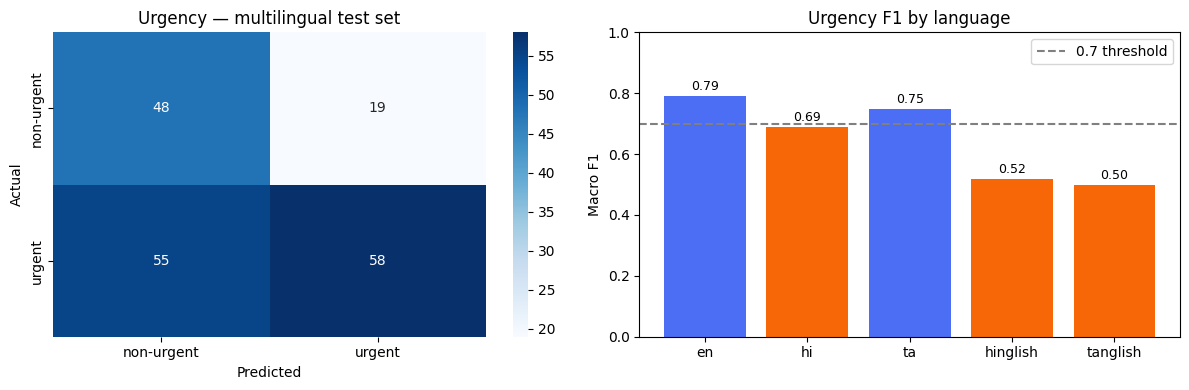

Plot saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/nlp_evaluation_v2.png


In [26]:
section('Full Pipeline Evaluation — Manual Test Set (180 samples)')

# Region accuracy
reg_acc = (df_manual['region_pred'] == df_manual['region']).mean()

# Resource F1
mlb2 = MultiLabelBinarizer(classes=['food','water','medicine'])
y_true_r = mlb2.fit_transform(df_manual['resources'].tolist())
y_pred_r = mlb2.transform(df_manual['resources_pred'].tolist())
res_f1   = f1_score(y_true_r, y_pred_r, average='macro', zero_division=0)

# Urgency F1
urg_f1 = f1_score(df_manual['urgency'].values, df_manual['urgency_pred'].values, average='macro')

print(f'Stage 2 — Language detection  : {lang_acc:.1%}  (180/180)')
print(f'Stage 6/7 — Region detection  : {reg_acc:.1%}')
print(f'Stage 7 — Resource F1 (macro) : {res_f1:.3f}  [manual test set]')
print(f'           Resource F1 (macro) : {f1_f8:.3f}  [Figure Eight — real ground truth]')
print(f'Stage 8 — Urgency F1 (macro)  : {urg_f1:.3f}  [multilingual]')
print(f'          Urgency F1 (macro)  : {results_en["eval_f1"]:.3f}  [English CrisisNLP+Fig8]')
print(f'          Urgency F1 (macro)  : {f1_kerala:.3f}  [Kerala domain test]')

print('\nPer-language urgency breakdown:')
for lang in config.LANGUAGES:
    mask = df_manual['lang'] == lang
    if mask.sum() == 0: continue
    f1 = f1_score(
        df_manual.loc[mask,'urgency'].values,
        df_manual.loc[mask,'urgency_pred'].values,
        average='macro', zero_division=0
    )
    print(f'  {lang:<12} F1={f1:.3f}  (n={mask.sum()})')

# Confusion matrix plot
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(df_manual['urgency'], df_manual['urgency_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-urgent','urgent'],
            yticklabels=['non-urgent','urgent'], ax=axes[0])
axes[0].set_title('Urgency — multilingual test set')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Per-language F1 bar chart
lang_f1s = {}
for lang in config.LANGUAGES:
    mask = df_manual['lang'] == lang
    if mask.sum() == 0: continue
    lang_f1s[lang] = f1_score(
        df_manual.loc[mask,'urgency'].values,
        df_manual.loc[mask,'urgency_pred'].values,
        average='macro', zero_division=0
    )

axes[1].bar(lang_f1s.keys(), lang_f1s.values(),
            color=['#4C6EF5' if v >= 0.7 else '#F76707' for v in lang_f1s.values()])
axes[1].axhline(0.7, linestyle='--', color='gray', label='0.7 threshold')
axes[1].set_title('Urgency F1 by language')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1)
axes[1].legend()
for i, (lang, v) in enumerate(lang_f1s.items()):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{config.OUT_PLOTS}/nlp_evaluation_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved -> {config.OUT_PLOTS}/nlp_evaluation_v2.png')

---
# End-to-End Pipeline Demo

In [27]:
section('End-to-end pipeline — single message through all 10 stages')

def run_pipeline(raw_text, lang_hint=None):
    result = {'input': raw_text}

    # Stage 2
    lang = detect_language(raw_text, lang_hint)
    result['stage2_lang'] = lang

    # Stage 3
    clean = normalise(raw_text, lang)
    result['stage3_clean'] = clean

    # Stage 4
    tok = tok_indic if lang in ('hi','ta') else tok_mbert
    enc = tok(clean, max_length=128, truncation=True, return_tensors='pt')
    tokens = tok.convert_ids_to_tokens(enc['input_ids'][0].tolist())
    result['stage4_tokens'] = len([t for t in tokens if t not in ('[PAD]','<pad>')])

    # Stage 5
    model = model_indic if lang in ('hi','ta') else model_mbert
    enc_g = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc_g)
    result['stage5_emb_dim'] = out.last_hidden_state[0,0,:].shape[0]

    # Stage 6
    ents   = ner_pipe(clean)
    result['stage6_entities'] = [(e['word'], e['entity_group'], f"{e['score']:.2f}") for e in ents]

    # Stage 7
    resources = extract_resources(clean)
    region    = text_to_region(clean, ents)
    disaster  = extract_disaster_type(clean)
    result['stage7_resources']     = resources
    result['stage7_region']        = region
    result['stage7_disaster_type'] = disaster

    # Stage 8 — mDeBERTa
    urg_pred, urg_score = get_urgency(clean, lang)
    result['stage8_urgency']       = urg_pred
    result['stage8_urgency_score'] = urg_score

    # Stage 9 — LaBSE embedding
    labse_vec = labse_model.encode([clean], normalize_embeddings=True)
    result['stage9_labse_dim'] = labse_vec.shape[1]

    # Stage 10
    result['stage10_demand'] = {
        'region'   : region,
        'resources': resources,
        'urgency'  : urg_pred,
        'disaster' : disaster,
    }
    return result


test_messages = [
    ('People stranded in north sector, need food and water urgently',     'en'),
    ('उत्तर में भोजन और पानी की सख्त जरूरत है',                         'hi'),
    ('வடக்கில் மக்கள் சிக்கியுள்ளனர், உணவு தேவை',                      'ta'),
    ('Flood aa gaya yaar, khana aur paani chahiye north mein',            'hinglish'),
    ('North la saapadu illai, thanni illai, urgent ah anupunga',          'tanglish'),
    ('Alappuzha mein bahut paani hai, log phanse hain, dawai chahiye',    'hinglish'),
    ('Chennai velachery la flood, hospital la medicine illai',            'tanglish'),
]

for msg, lang in test_messages:
    out = run_pipeline(msg, lang)
    print(f'\nInput [{lang}]: {msg[:70]}')
    print(f'  Lang     : {out["stage2_lang"]}')
    print(f'  Tokens   : {out["stage4_tokens"]}')
    print(f'  Entities : {out["stage6_entities"]}')
    print(f'  Resources: {out["stage7_resources"]}')
    print(f'  Region   : {out["stage7_region"]}')
    print(f'  Urgency  : {out["stage8_urgency"]} (score={out["stage8_urgency_score"]})')
    print(f'  -> Demand: {out["stage10_demand"]}')


  End-to-end pipeline — single message through all 10 stages

Input [en]: People stranded in north sector, need food and water urgently
  Lang     : en
  Tokens   : 16
  Entities : []
  Resources: ['food', 'water']
  Region   : north
  Urgency  : 1 (score=0.997)
  -> Demand: {'region': 'north', 'resources': ['food', 'water'], 'urgency': 1, 'disaster': 'general'}

Input [hi]: उत्तर में भोजन और पानी की सख्त जरूरत है
  Lang     : hi
  Tokens   : 14
  Entities : []
  Resources: ['food', 'water']
  Region   : central
  Urgency  : 1 (score=0.997)
  -> Demand: {'region': 'central', 'resources': ['food', 'water'], 'urgency': 1, 'disaster': 'general'}

Input [ta]: வடக்கில் மக்கள் சிக்கியுள்ளனர், உணவு தேவை
  Lang     : ta
  Tokens   : 16
  Entities : []
  Resources: ['food']
  Region   : central
  Urgency  : 1 (score=0.995)
  -> Demand: {'region': 'central', 'resources': ['food'], 'urgency': 1, 'disaster': 'general'}

Input [hinglish]: Flood aa gaya yaar, khana aur paani chahiye north mein
  La

In [28]:
section('Week 2 complete — deliverables checklist')

deliverables = [
    (f'{config.OUT_DEMAND}/region_demand.json',           'Regional demand vector (RL handoff)'),
    (f'{config.DATA_PROC}/emb_manual_mbert_indic.npy',   'mBERT+IndicBERT embeddings (manual test set)'),
    (f'{config.DATA_PROC}/emb_kerala_mbert.npy',         'mBERT embeddings (Kerala domain test)'),
    (f'{config.DATA_PROC}/emb_pipeline_labse.npy',       'LaBSE embeddings (pipeline rows)'),
    (f'{config.OUT_PLOTS}/nlp_evaluation_v2.png',        'NLP evaluation plots'),
    (f'{config.CKPT_DIR}/urgency_mdeberta_final/config.json', 'Fine-tuned mDeBERTa urgency model'),
]

all_ok = True
for path, desc in deliverables:
    exists = os.path.exists(path)
    if not exists: all_ok = False
    status = 'OK' if exists else 'MISSING'
    size   = f'  ({os.path.getsize(path)/1e6:.1f} MB)' if exists else ''
    print(f'  [{status}]  {desc}{size}')

print()
if all_ok:
    print('All deliverables present. Ready for Week 3 — RL Training.')
else:
    print('Some files missing — re-run the relevant cells above.')

print(f'\nKey handoff file for Week 3 RL agent:')
print(f'  {config.OUT_DEMAND}/region_demand.json')


  Week 2 complete — deliverables checklist
  [OK]  Regional demand vector (RL handoff)  (0.0 MB)
  [OK]  mBERT+IndicBERT embeddings (manual test set)  (0.6 MB)
  [OK]  mBERT embeddings (Kerala domain test)  (24.5 MB)
  [OK]  LaBSE embeddings (pipeline rows)  (0.6 MB)
  [OK]  NLP evaluation plots  (0.1 MB)
  [OK]  Fine-tuned mDeBERTa urgency model  (0.0 MB)

All deliverables present. Ready for Week 3 — RL Training.

Key handoff file for Week 3 RL agent:
  /content/drive/MyDrive/Equi-Relief/outputs/demand_vectors/region_demand.json
